# Chuẩn bị data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow import keras


In [ ]:
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/Công nghệ IoT nâng cao/final_data.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)
df.shape

(48233, 5)

In [ ]:
df = df.drop(columns="Unnamed: 0")

In [ ]:
# In ra tên giá trị cùng với số lần xuất hiện
value_counts = df['label'].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")


blazing_sun: 15860
Cold fog: 10055
lightly_sunlit: 9004
Sunny: 6767
pleasantly cool: 5784
Rainy: 763


In [ ]:
test =  df.iloc[:, :-1].values
check = np.array(test)
mean_values_column = np.mean(check, axis=0)
print("Giá trị trung bình trên các cột:", mean_values_column)

Giá trị trung bình trên các cột: [  30.56086393   63.89217299 1011.71668754]


In [ ]:
df.isna().sum()

,0
temperature,0
humidity,0
pressure,0
label,0


In [ ]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
df['label']= label_encoder.fit_transform(df['label'])
df['label'].unique()

array([3, 4, 5, 0, 2, 1])

In [ ]:
df.head()
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values
from sklearn.model_selection import train_test_split

# Split data for traditional ML models (2D)
X_train_sklearn, X_test_sklearn, y_train, y_test = train_test_split(X, Y, test_size=.2, random_state=41)

# Prepare data for CNN (3D)
# The original features are (temperature, humidity, pressure) - 3 features
# For Conv1D, we treat each of these as a step in a sequence with 1 feature each.
cnn_window_size = X_train_sklearn.shape[1] # Number of features in original data, which becomes window size for Conv1D
cnn_num_features = 1 # Each individual feature (temp, hum, press) is one input feature at each step of the Conv1D

X_train_cnn = X_train_sklearn.reshape(X_train_sklearn.shape[0], cnn_window_size, cnn_num_features)
X_test_cnn = X_test_sklearn.reshape(X_test_sklearn.shape[0], cnn_window_size, cnn_num_features)

In [ ]:
!pip install micromlgen

  Preparing metadata (setup.py) ... done
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32152 sha256=ad8d8f812730e44244366a4a57a11dab3875c254659ef6761edd4ce2a396b1d0
  Stored in directory: /root/.cache/pip/wheels/16/02/8a/3a8b533174e4f7691a8fd72dab4493fb6819b79f8fcc1d18a6
Successfully built micromlgen


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Model: DecisionTreeClassifier
Train time: 0.109071 seconds
Total predict time: 0.002299 seconds
Average predict time per sample: 0.00000024 seconds

Accuracy: 0.9984

--- Macro Average ---
Precision: 0.9986
Recall   : 0.9986
F1-score : 0.9986

--- Weighted Average ---
Precision: 0.9984
Recall   : 0.9984
F1-score : 0.9984

Cohen Kappa : 0.998
MCC         : 0.998

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00       136
           2       1.00      1.00      1.00      1364
           3       1.00      1.00      1.00      3191
           4       1.00      1.00      1.00      1817
           5       1.00      1.00      1.00      1139

    accuracy                           1.00      9647
   macro avg       1.00      1.00      1.00      9647
weighted avg       1.00      1.00      1.00      9647



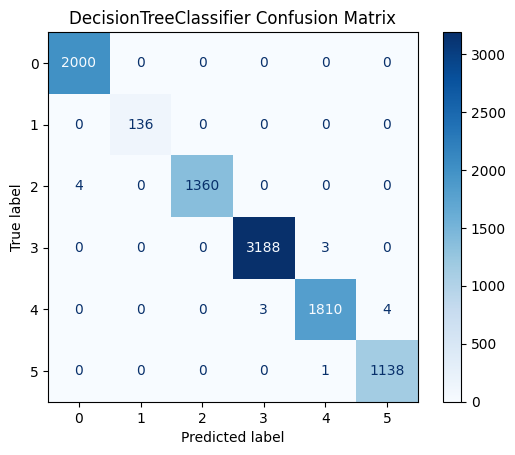

Model: SVC
Train time: 3.832918 seconds
Total predict time: 2.171076 seconds
Average predict time per sample: 0.00022505 seconds

Accuracy: 0.9772

--- Macro Average ---
Precision: 0.9744
Recall   : 0.9777
F1-score : 0.976

--- Weighted Average ---
Precision: 0.9772
Recall   : 0.9772
F1-score : 0.9772

Cohen Kappa : 0.9707
MCC         : 0.9707

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2000
           1       0.96      1.00      0.98       136
           2       0.99      0.96      0.97      1364
           3       0.98      0.99      0.99      3191
           4       0.97      0.97      0.97      1817
           5       0.97      0.97      0.97      1139

    accuracy                           0.98      9647
   macro avg       0.97      0.98      0.98      9647
weighted avg       0.98      0.98      0.98      9647



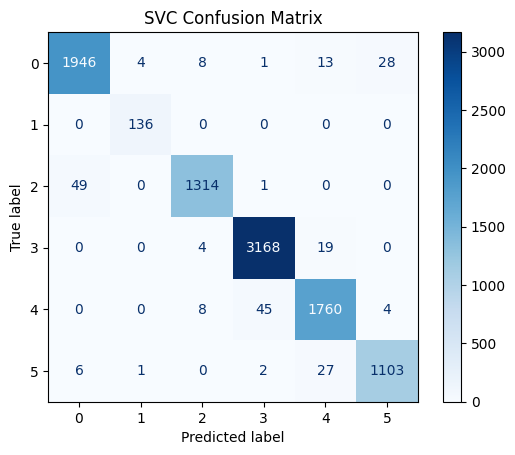

Model: RandomForestClassifier
Train time: 4.963786 seconds
Total predict time: 0.097469 seconds
Average predict time per sample: 0.00001010 seconds

Accuracy: 0.9969

--- Macro Average ---
Precision: 0.9961
Recall   : 0.9972
F1-score : 0.9966

--- Weighted Average ---
Precision: 0.9969
Recall   : 0.9969
F1-score : 0.9969

Cohen Kappa : 0.996
MCC         : 0.996

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       0.99      1.00      1.00       136
           2       1.00      1.00      1.00      1364
           3       1.00      1.00      1.00      3191
           4       1.00      0.99      0.99      1817
           5       0.99      1.00      1.00      1139

    accuracy                           1.00      9647
   macro avg       1.00      1.00      1.00      9647
weighted avg       1.00      1.00      1.00      9647



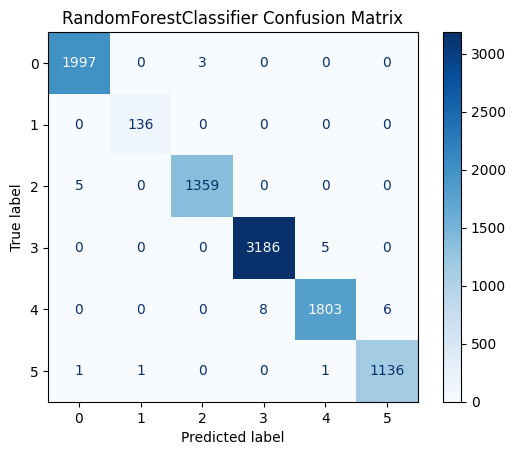

In [ ]:
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ======================
# STORE RESULTS
# ======================
results = []

classifiers = [
    DecisionTreeClassifier(criterion="entropy", random_state=41),
    svm.SVC(gamma='auto', C=1.0, kernel='rbf'),
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1),
]

for model in classifiers:

    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy='minority')),
        ('classifier', model)
    ])

    # ======================
    # TRAIN TIME
    # ======================
    start_train = time.perf_counter()
    pipeline.fit(X_train_sklearn, y_train)
    end_train = time.perf_counter()
    train_time = end_train - start_train

    # ======================
    # PREDICT TIME
    # ======================
    start_predict = time.perf_counter()
    y_hat = pipeline.predict(X_test_sklearn)
    end_predict = time.perf_counter()

    predict_time = end_predict - start_predict
    avg_predict_time = predict_time / len(X_test_sklearn)

    # ======================
    # METRICS
    # ======================
    accuracy = accuracy_score(y_test, y_hat)

    precision_macro = precision_score(y_test, y_hat, average='macro')
    recall_macro = recall_score(y_test, y_hat, average='macro')
    f1_macro = f1_score(y_test, y_hat, average='macro')

    precision_weighted = precision_score(y_test, y_hat, average='weighted')
    recall_weighted = recall_score(y_test, y_hat, average='weighted')
    f1_weighted = f1_score(y_test, y_hat, average='weighted')

    kappa = cohen_kappa_score(y_test, y_hat)
    mcc = matthews_corrcoef(y_test, y_hat)

    # ======================
    # SAVE RESULT
    # ======================
    results.append({
        "Model": model.__class__.__name__,
        "Train Time (s)": train_time,
        "Predict Time (s)": predict_time,
        "Predict Time per Sample (s)": avg_predict_time,
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "Cohen Kappa": kappa,
        "MCC": mcc
    })

    # ======================
    # PRINT RESULTS
    # ======================
    print("="*60)
    print("Model:", model.__class__.__name__)
    print("="*60)

    print("Train time: {:.6f} seconds".format(train_time))
    print("Total predict time: {:.6f} seconds".format(predict_time))
    print("Average predict time per sample: {:.8f} seconds".format(avg_predict_time))

    print("\nAccuracy:", round(accuracy, 4))

    print("\n--- Macro Average ---")
    print("Precision:", round(precision_macro, 4))
    print("Recall   :", round(recall_macro, 4))
    print("F1-score :", round(f1_macro, 4))

    print("\n--- Weighted Average ---")
    print("Precision:", round(precision_weighted, 4))
    print("Recall   :", round(recall_weighted, 4))
    print("F1-score :", round(f1_weighted, 4))

    print("\nCohen Kappa :", round(kappa, 4))
    print("MCC         :", round(mcc, 4))

    print("\n===== Classification Report =====")
    print(classification_report(y_test, y_hat))

    # ======================
    # CONFUSION MATRIX
    # ======================
    cm = confusion_matrix(y_test, y_hat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(model.__class__.__name__ + " Confusion Matrix")
    plt.show()


In [ ]:
from micromlgen import port
model = DecisionTreeClassifier(criterion="entropy",random_state=41)
model.fit(X_train_sklearn, y_train)

y_hat = model.predict(X_test_sklearn)
print(classification_report(y_test, y_hat))
print(accuracy_score(y_test,y_hat))
print(port(model))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00       136
           2       1.00      1.00      1.00      1364
           3       1.00      1.00      1.00      3191
           4       1.00      1.00      1.00      1817
           5       1.00      1.00      1.00      1139

    accuracy                           1.00      9647
   macro avg       1.00      1.00      1.00      9647
weighted avg       1.00      1.00      1.00      9647

0.9981341349642376
#pragma once
#include <cstdarg>
namespace Eloquent {
    namespace ML {
        namespace Port {
            class DecisionTree {
                public:
                    /**
                    * Predict class for features vector
                    */
                    int predict(float *x) {
                        if (x[0] <= 29.994999885559082) {
                            if (x[2] <= 1013.4949951171875) {
                 

In [ ]:
# lưu file
with open("ModelDT.h", "w") as f:
    f.write(port(model))

print("Đã lưu model vào decision_tree_model.h")

Đã lưu model vào decision_tree_model.h


In [ ]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import to_categorical


window_size = cnn_window_size # Use the globally defined cnn_window_size from data prep
num_features = cnn_num_features # Use the globally defined cnn_num_features from data prep
num_classes = len(np.unique(y_train))

model_cnn = models.Sequential([
    Input(shape=(window_size, num_features)),

    layers.Conv1D(16, 2, activation='relu'),

    layers.Flatten(),

    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # chuẩn cho multiclass integer labels
    metrics=['accuracy']
)

model_cnn.summary()

history = model_cnn.fit(
    X_train_cnn, # Use CNN-specific training data
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.25 # Removed as validation_data is provided
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 2, 16)          │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,302 (5.09 KB)

 Trainable params: 1,302 (5.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4493 - loss: 15.5664 - val_accuracy: 0.6517 - val_loss: 1.0193
Epoch 2/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6347 - loss: 1.0233 - val_accuracy: 0.5903 - val_loss: 1.4030
Epoch 3/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6698 - loss: 0.9409 - val_accuracy: 0.7332 - val_loss: 0.8900
Epoch 4/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6719 - loss: 0.9011 - val_accuracy: 0.7133 - val_loss: 0.8141
Epoch 5/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6904 - loss: 0.8558 - val_accuracy: 0.7037 - val_loss: 1.0723
Epoch 6/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6880 - loss: 0.8593 - val_accuracy: 0.6769 - val_loss: 0.9754
Epoch 7/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7038 - loss: 0.8062 - val_accuracy: 0.6715 - val_loss: 0.7484
Epoch 8/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7103 - loss: 0.7696 - val_acc

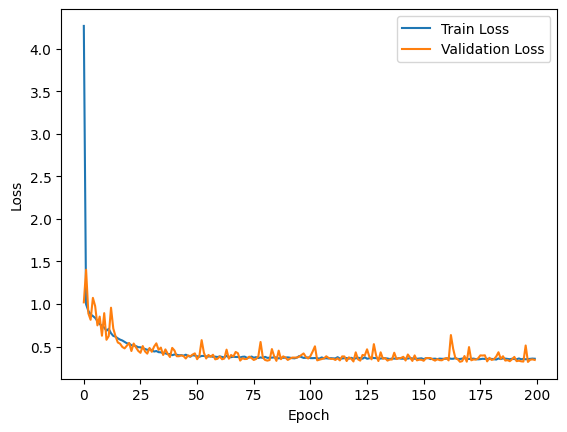

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# X_test_cnn = X_test.reshape(X_test.shape[0], cnn_window_size, cnn_num_features)
# predict
# y_pred_prob = model_cnn.predict(X_test_cnn) # Use CNN-specific test data

# convert xác suất → class label


302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Model Evaluation
Total predict time: 0.741804 seconds
Average predict time per sample: 0.00007689 seconds

Accuracy: 0.8614

--- Macro Average ---
Precision: 0.8401
Recall   : 0.8593
F1-score : 0.8475

--- Weighted Average ---
Precision: 0.865
Recall   : 0.8614
F1-score : 0.8618

Cohen Kappa : 0.8223
MCC         : 0.8229

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2000
           1       0.90      0.99      0.94       136
           2       0.67      0.62      0.65      1364
           3       0.95      0.95      0.95      3191
           4       0.87      0.85      0.86      1817
           5       0.70      0.87      0.77      1139

    accuracy                           0.86      9647
   macro avg       0.84      0.86      0.85      9647
weighted avg       0.87      0.86      0.86      9647



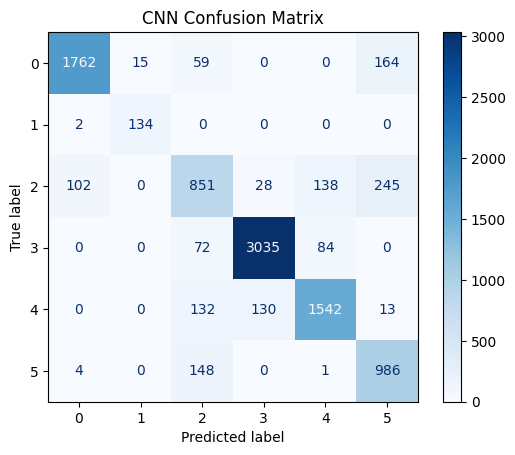

In [ ]:
import numpy as np
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# ======================
# MEASURE PREDICT TIME
# ======================
start_predict = time.perf_counter()

y_pred_prob = model_cnn.predict(X_test_cnn)

end_predict = time.perf_counter()

predict_time = end_predict - start_predict
avg_predict_time = predict_time / len(X_test_cnn)

# convert probability → label
y_pred_cnn = np.argmax(y_pred_prob, axis=1)

# ======================
# BASIC METRICS
# ======================
accuracy = accuracy_score(y_test, y_pred_cnn)

precision_macro = precision_score(y_test, y_pred_cnn, average='macro')
recall_macro = recall_score(y_test, y_pred_cnn, average='macro')
f1_macro = f1_score(y_test, y_pred_cnn, average='macro')

precision_weighted = precision_score(y_test, y_pred_cnn, average='weighted')
recall_weighted = recall_score(y_test, y_pred_cnn, average='weighted')
f1_weighted = f1_score(y_test, y_pred_cnn, average='weighted')

# advanced metrics
kappa = cohen_kappa_score(y_test, y_pred_cnn)
mcc = matthews_corrcoef(y_test, y_pred_cnn)

# ======================
# PRINT RESULTS
# ======================
print("="*60)
print("CNN Model Evaluation")
print("="*60)

print("Total predict time: {:.6f} seconds".format(predict_time))
print("Average predict time per sample: {:.8f} seconds".format(avg_predict_time))

print("\nAccuracy:", round(accuracy, 4))

print("\n--- Macro Average ---")
print("Precision:", round(precision_macro, 4))
print("Recall   :", round(recall_macro, 4))
print("F1-score :", round(f1_macro, 4))

print("\n--- Weighted Average ---")
print("Precision:", round(precision_weighted, 4))
print("Recall   :", round(recall_weighted, 4))
print("F1-score :", round(f1_weighted, 4))

print("\nCohen Kappa :", round(kappa, 4))
print("MCC         :", round(mcc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn))

# ======================
# CONFUSION MATRIX
# ======================
cm = confusion_matrix(y_test, y_pred_cnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
    # ======================
    # SAVE RESULT
    # ======================
results.append({
        "Model": "CNN",
        "Train Time (s)": train_time,
        "Predict Time (s)": predict_time,
        "Predict Time per Sample (s)": avg_predict_time,
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "Cohen Kappa": kappa,
        "MCC": mcc
    })


In [ ]:
# ======================
# EXPORT CSV
# ======================
results_df = pd.DataFrame(results)

# sort by accuracy (optional)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# save file
results_df.to_csv("sklearn_model_results.csv", index=False)

print("\nSaved to sklearn_model_results.csv")
print(results_df)


Saved to sklearn_model_results.csv
                    Model  Train Time (s)  Predict Time (s)  \
0  DecisionTreeClassifier        0.109071          0.002299   
2  RandomForestClassifier        4.963786          0.097469   
1                     SVC        3.832918          2.171076   
3                     CNN        4.963786          0.741804   

   Predict Time per Sample (s)  Accuracy  Precision Macro  Recall Macro  \
0                 2.382943e-07  0.998445         0.998559      0.998566   
2                 1.010357e-05  0.996890         0.996071      0.997155   
1                 2.250520e-04  0.977195         0.974367      0.977693   
3                 7.689477e-05  0.861408         0.840059      0.859272   

   F1 Macro  Precision Weighted  Recall Weighted  F1 Weighted  Cohen Kappa  \
0  0.998562            0.998446         0.998445     0.998445     0.998001   
2  0.996609            0.996891         0.996890     0.996889     0.996003   
1  0.975953            0.977206       